# 📚 Tugas Pertemuan 12 — Logistic Regression & Two-Class Classification

**Mata Kuliah:** Introduction to AI  
**Tema:** Deteksi Komentar Toxic / Non-toxic di Media Sosial

---

## Tujuan
Menerapkan logistic regression untuk mengklasifikasikan komentar media sosial menjadi dua kelas:
- **1 = Toxic**
- **0 = Non-toxic**

## 1. Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

print("✅ Semua library berhasil diimport!")

✅ Semua library berhasil diimport!


## 2. Dataset — 20 Komentar Media Sosial

Dataset berisi komentar dalam Bahasa Indonesia dengan label:
- `0` = Non-toxic (komentar sopan, positif, atau netral)
- `1` = Toxic (komentar kasar, menghina, atau negatif)

In [2]:
data = {
    "komentar": [
        # Non-toxic (0)
        "kontennya bagus dan sangat informatif",
        "saya tidak setuju tapi terima kasih atas penjelasannya",
        "penjelasannya membantu sekali buat pemula seperti saya",
        "sangat bermanfaat untuk belajar lebih lanjut",
        "terima kasih banyak sudah berbagi ilmu",
        "konten yang sangat edukatif dan mudah dipahami",
        "saya suka cara penyampaiannya yang jelas",
        "lanjutkan terus kontennya sangat membantu",
        "penjelasan yang detail dan mudah dimengerti",
        "keren sekali videonya semoga makin sukses",
        # Toxic (1)
        "lu goblok banget sih tidak ngerti juga",
        "akun paling tolol yang pernah saya lihat",
        "isi videonya sampah semua tidak berguna",
        "jelek dan tidak jelas sama sekali buang waktu",
        "dasar otak udang tidak berguna bikin konten",
        "malu deh jadi orang yang bikin konten kayak gitu",
        "bego banget sih tidak bisa bikin konten yang bagus",
        "konten paling sampah yang pernah ada di internet",
        "ngapain nonton ini buang waktu doang tidak ada isinya",
        "tolol sekali pembuatnya tidak tahu apa apa"
    ],
    "label": [0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
              1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
}

df = pd.DataFrame(data)

# Tambah kolom kelas untuk tampilan
df["kelas"] = df["label"].map({0: "Non-toxic", 1: "Toxic"})

print(f"Total data: {len(df)} komentar")
print(f"Non-toxic (0): {sum(df.label == 0)}")
print(f"Toxic    (1): {sum(df.label == 1)}")
print()
df

Total data: 20 komentar
Non-toxic (0): 10
Toxic    (1): 10



,komentar,label,kelas
0,kontennya bagus dan sangat informatif,0,Non-toxic
1,saya tidak setuju tapi terima kasih atas penje...,0,Non-toxic
2,penjelasannya membantu sekali buat pemula sepe...,0,Non-toxic
3,sangat bermanfaat untuk belajar lebih lanjut,0,Non-toxic
4,terima kasih banyak sudah berbagi ilmu,0,Non-toxic
5,konten yang sangat edukatif dan mudah dipahami,0,Non-toxic
6,saya suka cara penyampaiannya yang jelas,0,Non-toxic
7,lanjutkan terus kontennya sangat membantu,0,Non-toxic
8,penjelasan yang detail dan mudah dimengerti,0,Non-toxic
9,keren sekali videonya semoga makin sukses,0,Non-toxic


## 3. Visualisasi Distribusi Data

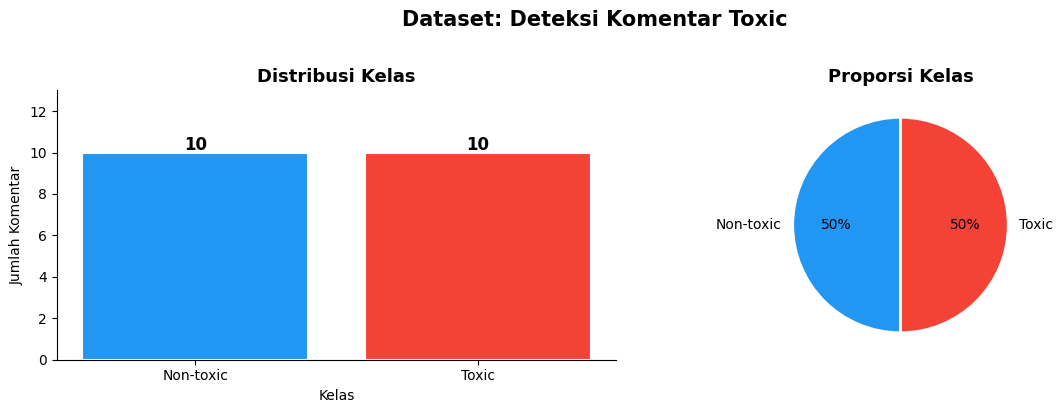

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart distribusi kelas
counts = df["kelas"].value_counts()
colors = ["#2196F3", "#F44336"]
axes[0].bar(counts.index, counts.values, color=colors, edgecolor="white", linewidth=1.5)
axes[0].set_title("Distribusi Kelas", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Kelas")
axes[0].set_ylabel("Jumlah Komentar")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 0.1, str(v), ha="center", fontweight="bold", fontsize=12)
axes[0].set_ylim(0, 13)
axes[0].spines[["top", "right"]].set_visible(False)

# Pie chart
axes[1].pie(
    counts.values,
    labels=counts.index,
    colors=colors,
    autopct="%1.0f%%",
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2}
)
axes[1].set_title("Proporsi Kelas", fontsize=13, fontweight="bold")

plt.suptitle("Dataset: Deteksi Komentar Toxic", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 4. Fitur yang Digunakan

Fitur yang relevan untuk mendeteksi komentar toxic:

| Fitur | Deskripsi | Contoh |
|-------|-----------|--------|
| **x₁** | Ada kata kasar | "goblok", "bego", "tolol" |
| **x₂** | Ada hinaan langsung | "dasar", "malu" |
| **x₃** | Ada kata negatif kuat | "sampah", "buang waktu", "tidak berguna" |
| **x₄** | Ada kata apresiasi | "bagus", "terima kasih", "membantu" |

Pada implementasi ini kita gunakan **CountVectorizer** (bag-of-words) yang secara otomatis mengubah seluruh kosakata menjadi fitur numerik — jauh lebih komprehensif dari empat fitur manual di atas.

In [4]:
# Representasi fitur manual (ilustrasi)
def ekstrak_fitur_manual(komentar):
    kata_kasar     = ["goblok", "tolol", "bego", "bodoh", "udang"]
    kata_hinaan    = ["dasar", "malu", "kayak"]
    kata_negatif   = ["sampah", "jelek", "buang", "tidak berguna", "ngapain"]
    kata_apresiasi = ["bagus", "terima kasih", "membantu", "bermanfaat", "keren", "sukses"]

    k = komentar.lower()
    x1 = int(any(w in k for w in kata_kasar))
    x2 = int(any(w in k for w in kata_hinaan))
    x3 = int(any(w in k for w in kata_negatif))
    x4 = int(any(w in k for w in kata_apresiasi))
    return x1, x2, x3, x4

fitur_rows = []
for _, row in df.iterrows():
    x1, x2, x3, x4 = ekstrak_fitur_manual(row["komentar"])
    fitur_rows.append({
        "komentar": row["komentar"][:40] + "..." if len(row["komentar"]) > 40 else row["komentar"],
        "x1_kata_kasar": x1,
        "x2_hinaan": x2,
        "x3_negatif": x3,
        "x4_apresiasi": x4,
        "label": row["label"]
    })

df_fitur = pd.DataFrame(fitur_rows)
print("Representasi Fitur Manual (ilustrasi):")
df_fitur

Representasi Fitur Manual (ilustrasi):


,komentar,x1_kata_kasar,x2_hinaan,x3_negatif,x4_apresiasi,label
0,kontennya bagus dan sangat informatif,0,0,0,1,0
1,saya tidak setuju tapi terima kasih atas...,0,0,0,1,0
2,penjelasannya membantu sekali buat pemul...,0,0,0,1,0
3,sangat bermanfaat untuk belajar lebih la...,0,0,0,1,0
4,terima kasih banyak sudah berbagi ilmu,0,0,0,1,0
5,konten yang sangat edukatif dan mudah di...,0,0,0,0,0
6,saya suka cara penyampaiannya yang jelas,0,0,0,0,0
7,lanjutkan terus kontennya sangat membant...,0,0,0,1,0
8,penjelasan yang detail dan mudah dimenge...,0,0,0,0,0
9,keren sekali videonya semoga makin sukse...,0,0,0,1,0


## 5. Preprocessing — CountVectorizer (Bag-of-Words)

In [5]:
# Ekstraksi fitur dengan CountVectorizer
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(df["komentar"])
y = df["label"]

print(f"Jumlah komentar   : {X.shape[0]}")
print(f"Jumlah fitur kata : {X.shape[1]}")
print()
print("Contoh 20 kata dalam vocabulary:")
vocab = vectorizer.get_feature_names_out()
print(list(vocab[:20]))

Jumlah komentar   : 20
Jumlah fitur kata : 88

Contoh 20 kata dalam vocabulary:
['ada', 'akun', 'apa', 'atas', 'bagus', 'banget', 'banyak', 'bego', 'belajar', 'berbagi', 'berguna', 'bermanfaat', 'bikin', 'bisa', 'buang', 'buat', 'cara', 'dan', 'dasar', 'deh']


In [6]:
# Tampilkan matriks fitur sebagai DataFrame (sebagian)
df_matrix = pd.DataFrame(X.toarray(), columns=vocab)
df_matrix["LABEL"] = y.values
print("Matriks fitur (10 baris pertama, 15 kolom pertama):")
df_matrix.iloc[:10, list(range(15)) + [-1]]

Matriks fitur (10 baris pertama, 15 kolom pertama):


,ada,akun,apa,atas,bagus,banget,banyak,bego,belajar,berbagi,berguna,bermanfaat,bikin,bisa,buang,LABEL
0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0
4,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
7,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
8,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
9,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


## 6. Split Data Training & Testing

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f"Total data         : {X.shape[0]}")
print(f"Data training (75%): {X_train.shape[0]}")
print(f"Data testing  (25%): {X_test.shape[0]}")
print()
print(f"Distribusi training — Non-toxic: {sum(y_train==0)}, Toxic: {sum(y_train==1)}")
print(f"Distribusi testing  — Non-toxic: {sum(y_test==0)},  Toxic: {sum(y_test==1)}")

Total data         : 20
Data training (75%): 15
Data testing  (25%): 5

Distribusi training — Non-toxic: 7, Toxic: 8
Distribusi testing  — Non-toxic: 3,  Toxic: 2


## 7. Visualisasi Fungsi Sigmoid

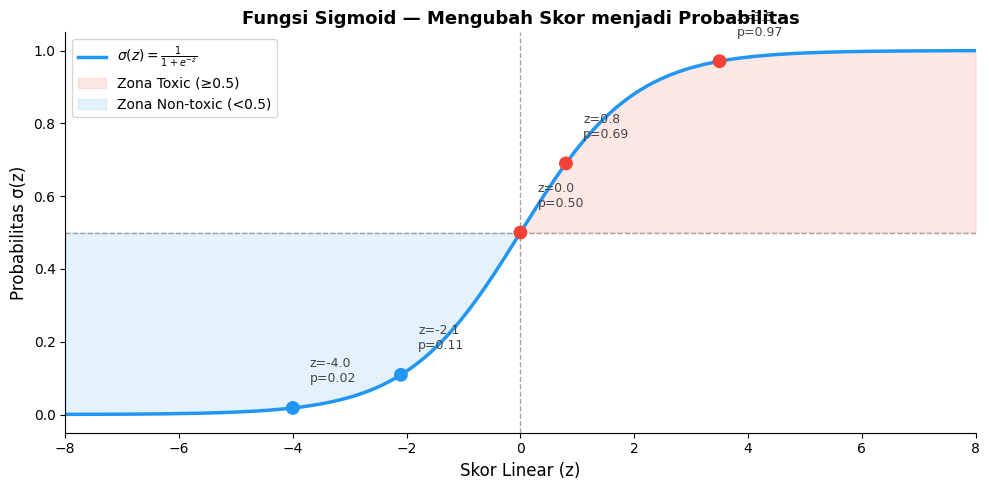

In [8]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z = np.linspace(-8, 8, 300)
sigma = sigmoid(z)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(z, sigma, color="#2196F3", linewidth=2.5, label=r"$\sigma(z) = \frac{1}{1+e^{-z}}$")

# Garis threshold
ax.axhline(0.5, color="gray", linestyle="--", linewidth=1, alpha=0.7)
ax.axvline(0,   color="gray", linestyle="--", linewidth=1, alpha=0.7)

# Warna zona
ax.fill_between(z, 0.5, sigma, where=(sigma >= 0.5), alpha=0.12, color="#F44336", label="Zona Toxic (≥0.5)")
ax.fill_between(z, sigma, 0.5, where=(sigma < 0.5),  alpha=0.12, color="#2196F3", label="Zona Non-toxic (<0.5)")

# Titik contoh
contoh_z  = [3.5, 0.8, 0.0, -2.1, -4.0]
contoh_p  = [sigmoid(z_) for z_ in contoh_z]
contoh_c  = ["#F44336" if p >= 0.5 else "#2196F3" for p in contoh_p]
ax.scatter(contoh_z, contoh_p, color=contoh_c, s=80, zorder=5)
for z_, p_ in zip(contoh_z, contoh_p):
    ax.annotate(f"z={z_}\np={p_:.2f}",
                xy=(z_, p_), xytext=(z_+0.3, p_+0.07),
                fontsize=9, color="#444")

ax.set_xlabel("Skor Linear (z)", fontsize=12)
ax.set_ylabel("Probabilitas σ(z)", fontsize=12)
ax.set_title("Fungsi Sigmoid — Mengubah Skor menjadi Probabilitas", fontsize=13, fontweight="bold")
ax.legend(loc="upper left", fontsize=10)
ax.set_xlim(-8, 8)
ax.set_ylim(-0.05, 1.05)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

## 8. Latih Model Logistic Regression

In [9]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

print("✅ Model berhasil dilatih!")
print(f"   Solver    : {model.solver}")
print(f"   Max iter  : {model.max_iter}")
print(f"   Kelas     : {model.classes_}  (0=Non-toxic, 1=Toxic)")

✅ Model berhasil dilatih!
   Solver    : lbfgs
   Max iter  : 1000
   Kelas     : [0 1]  (0=Non-toxic, 1=Toxic)


## 9. Prediksi & Probabilitas pada Data Testing

In [10]:
y_pred  = model.predict(X_test)
y_proba = model.predict_proba(X_test)

# Ambil komentar asli dari data test
test_indices = y_test.index.tolist()

hasil = pd.DataFrame({
    "komentar"        : [df.loc[i, "komentar"] for i in test_indices],
    "label_asli"      : y_test.values,
    "prediksi"        : y_pred,
    "prob_non_toxic"  : y_proba[:, 0].round(3),
    "prob_toxic"      : y_proba[:, 1].round(3),
    "benar"           : (y_test.values == y_pred)
})

hasil["status"] = hasil["benar"].map({True: "✅ Benar", False: "❌ Salah"})

print("Hasil prediksi pada data testing:")
hasil.drop(columns=["benar"])

Hasil prediksi pada data testing:


,komentar,label_asli,prediksi,prob_non_toxic,prob_toxic,status
0,terima kasih banyak sudah berbagi ilmu,0,0,0.646,0.354,✅ Benar
1,lanjutkan terus kontennya sangat membantu,0,0,0.714,0.286,✅ Benar
2,konten paling sampah yang pernah ada di internet,1,1,0.300,0.700,✅ Benar
3,dasar otak udang tidak berguna bikin konten,1,1,0.221,0.779,✅ Benar
4,sangat bermanfaat untuk belajar lebih lanjut,0,0,0.633,0.367,✅ Benar


## 10. Evaluasi Model

In [11]:
acc = accuracy_score(y_test, y_pred)
print("=" * 45)
print(f"  ACCURACY  : {acc:.2%}")
print("=" * 45)
print()
print("Classification Report:")
print(classification_report(y_test, y_pred,
                             target_names=["Non-toxic (0)", "Toxic (1)"]))

  ACCURACY  : 100.00%

Classification Report:
               precision    recall  f1-score   support

Non-toxic (0)       1.00      1.00      1.00         3
    Toxic (1)       1.00      1.00      1.00         2

     accuracy                           1.00         5
    macro avg       1.00      1.00      1.00         5
 weighted avg       1.00      1.00      1.00         5



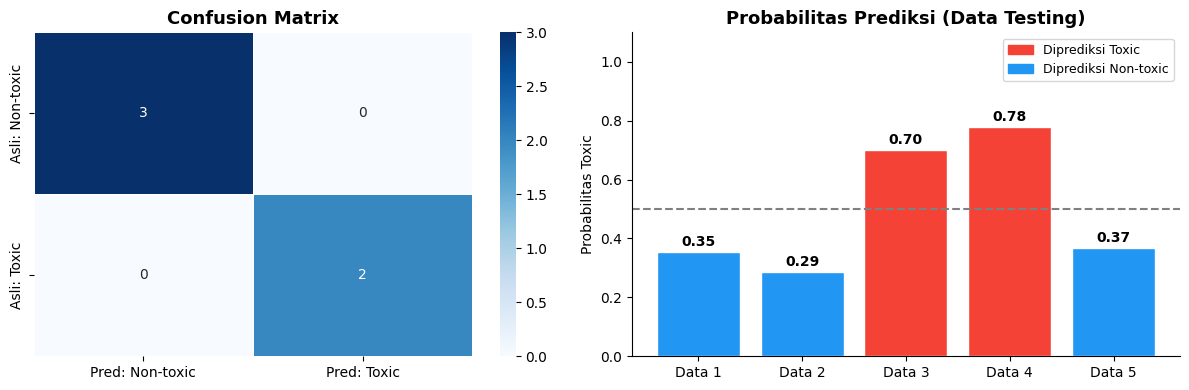

In [12]:
# Visualisasi Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Confusion matrix heatmap
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Pred: Non-toxic", "Pred: Toxic"],
    yticklabels=["Asli: Non-toxic", "Asli: Toxic"],
    ax=axes[0], linewidths=0.5, linecolor="white"
)
axes[0].set_title("Confusion Matrix", fontsize=13, fontweight="bold")

# Bar chart probabilitas
x_pos = range(len(hasil))
bars = axes[1].bar(x_pos, hasil["prob_toxic"], color=[
    "#F44336" if p >= 0.5 else "#2196F3" for p in hasil["prob_toxic"]
], edgecolor="white", linewidth=1)
axes[1].axhline(0.5, color="gray", linestyle="--", linewidth=1.5, label="Threshold 0.5")
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels([f"Data {i+1}" for i in x_pos], rotation=0)
axes[1].set_ylabel("Probabilitas Toxic")
axes[1].set_title("Probabilitas Prediksi (Data Testing)", fontsize=13, fontweight="bold")
axes[1].set_ylim(0, 1.1)
axes[1].legend()
axes[1].spines[["top", "right"]].set_visible(False)

toxic_patch    = mpatches.Patch(color="#F44336", label="Diprediksi Toxic")
nontoxic_patch = mpatches.Patch(color="#2196F3", label="Diprediksi Non-toxic")
axes[1].legend(handles=[toxic_patch, nontoxic_patch], loc="upper right", fontsize=9)

for bar, prob in zip(bars, hasil["prob_toxic"]):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f"{prob:.2f}", ha="center", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()

## 11. Prediksi Komentar Baru

In [13]:
komentar_baru = [
    "kamu tidak berguna sama sekali tolol banget",
    "terima kasih videonya sangat membantu belajar",
    "konten sampah tidak ada gunanya nonton ini",
    "penjelasan yang bagus dan mudah dipahami",
    "dasar bodoh tidak bisa bikin konten yang benar"
]

X_baru = vectorizer.transform(komentar_baru)
pred_baru  = model.predict(X_baru)
proba_baru = model.predict_proba(X_baru)

print("\nHasil Prediksi Komentar Baru:")
print("-" * 70)
for i, komentar in enumerate(komentar_baru):
    kelas = "🔴 TOXIC" if pred_baru[i] == 1 else "🟢 NON-TOXIC"
    p_nontoxic = proba_baru[i][0]
    p_toxic    = proba_baru[i][1]
    print(f"Komentar : \"{komentar}\"")
    print(f"Prediksi : {kelas}")
    print(f"Prob     : Non-toxic={p_nontoxic:.3f}  |  Toxic={p_toxic:.3f}")
    print("-" * 70)


Hasil Prediksi Komentar Baru:
----------------------------------------------------------------------
Komentar : "kamu tidak berguna sama sekali tolol banget"
Prediksi : 🔴 TOXIC
Prob     : Non-toxic=0.159  |  Toxic=0.841
----------------------------------------------------------------------
Komentar : "terima kasih videonya sangat membantu belajar"
Prediksi : 🟢 NON-TOXIC
Prob     : Non-toxic=0.766  |  Toxic=0.234
----------------------------------------------------------------------
Komentar : "konten sampah tidak ada gunanya nonton ini"
Prediksi : 🔴 TOXIC
Prob     : Non-toxic=0.215  |  Toxic=0.785
----------------------------------------------------------------------
Komentar : "penjelasan yang bagus dan mudah dipahami"
Prediksi : 🟢 NON-TOXIC
Prob     : Non-toxic=0.790  |  Toxic=0.210
----------------------------------------------------------------------
Komentar : "dasar bodoh tidak bisa bikin konten yang benar"
Prediksi : 🔴 TOXIC
Prob     : Non-toxic=0.233  |  Toxic=0.767
----------

## 12. Visualisasi Kata Berpengaruh (Bobot Model)

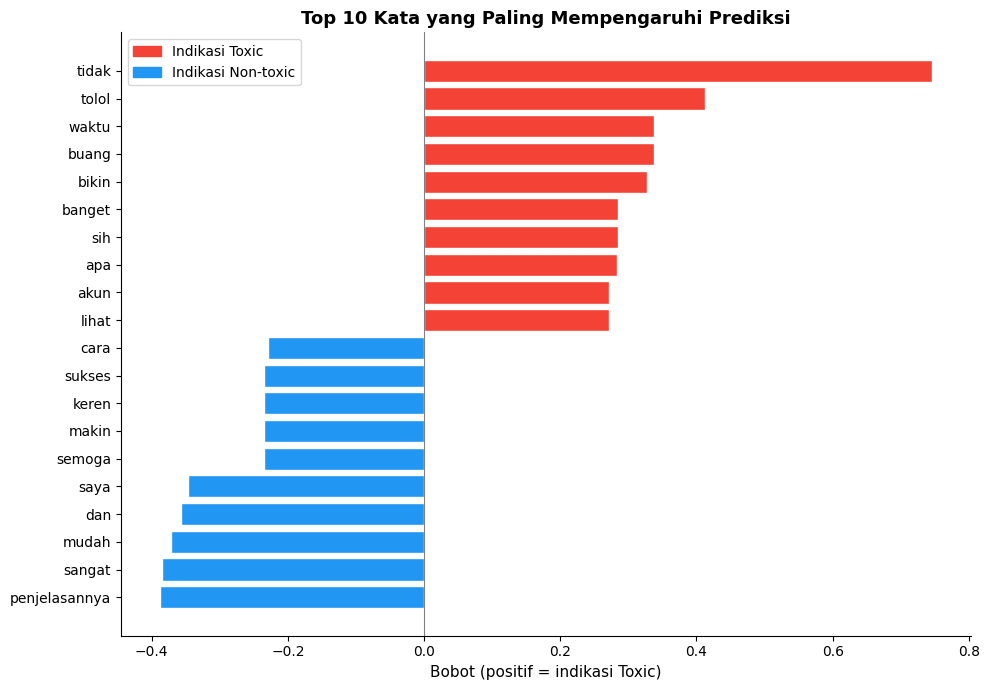


5 kata paling menunjukkan TOXIC:
 kata    bobot
bikin 0.327321
buang 0.337814
waktu 0.337814
tolol 0.412753
tidak 0.746408

5 kata paling menunjukkan NON-TOXIC:
         kata     bobot
penjelasannya -0.388454
       sangat -0.385387
        mudah -0.371908
          dan -0.357245
         saya -0.346909


In [14]:
# Ekstrak bobot dari model
feature_names = vectorizer.get_feature_names_out()
coef = model.coef_[0]

df_coef = pd.DataFrame({"kata": feature_names, "bobot": coef})
df_coef = df_coef.sort_values("bobot")

# Top 10 kata paling toxic dan paling non-toxic
top_toxic    = df_coef.tail(10)
top_nontoxic = df_coef.head(10)
top_gabung   = pd.concat([top_nontoxic, top_toxic])

fig, ax = plt.subplots(figsize=(10, 7))
colors = ["#F44336" if b > 0 else "#2196F3" for b in top_gabung["bobot"]]
bars = ax.barh(top_gabung["kata"], top_gabung["bobot"], color=colors, edgecolor="white")
ax.axvline(0, color="gray", linewidth=0.8)
ax.set_xlabel("Bobot (positif = indikasi Toxic)", fontsize=11)
ax.set_title("Top 10 Kata yang Paling Mempengaruhi Prediksi", fontsize=13, fontweight="bold")

toxic_patch    = mpatches.Patch(color="#F44336", label="Indikasi Toxic")
nontoxic_patch = mpatches.Patch(color="#2196F3", label="Indikasi Non-toxic")
ax.legend(handles=[toxic_patch, nontoxic_patch])
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

print("\n5 kata paling menunjukkan TOXIC:")
print(df_coef.tail(5)[["kata", "bobot"]].to_string(index=False))
print("\n5 kata paling menunjukkan NON-TOXIC:")
print(df_coef.head(5)[["kata", "bobot"]].to_string(index=False))

## 13. Kesimpulan

Logistic regression bekerja dengan mengubah teks komentar menjadi representasi numerik melalui *CountVectorizer*, kemudian menghitung skor linear dari bobot tiap kata, dan mengubah skor tersebut menjadi probabilitas menggunakan fungsi sigmoid **σ(z) = 1/(1+e⁻ᶻ)**. Model dilatih dengan memaksimalkan *likelihood* — yaitu mencari bobot yang membuat prediksi paling sering benar terhadap data training.

**Kelebihan probabilitas dibanding keputusan keras:**

| Aspek | Perceptron (keputusan keras) | Logistic Regression (probabilistik) |
|-------|------------------------------|--------------------------------------|
| Output | `0` atau `1` langsung | Probabilitas `0.0` – `1.0` |
| Informasi | "Toxic" / "Non-toxic" | "87% kemungkinan Toxic" |
| Fleksibilitas | Threshold tetap di 0 | Threshold bisa diatur (0.3, 0.7, dll) |
| Kegunaan praktis | Klasifikasi dasar | Moderasi bertingkat, prioritas review |

Dengan probabilitas, platform moderasi dapat:
- **Auto-remove** komentar dengan prob toxic > 0.90
- **Human review** untuk prob toxic 0.50 – 0.90  
- **Loloskan** komentar dengan prob toxic < 0.50